# Quotes Full C+D

Notebook especifico para auditar el `current` final mergeado `C + D` de `quotes`.

Replica el patron de granularidad usado en `trades`, pero adaptado a la microestructura de `quotes`: mercado cruzado, enterizacion de `ask`, drift temporal y anatomia de files pequenos.

## 1. Carga comun del current final y sus variantes C / D

Primero se cargan los tres materializados (`C+D`, `D`, `C`) y se normalizan `issues`, `warns` y `metrics_json` para poder lanzar analitica agregada desde celdas ligeras.

In [1]:
import gc
import runpy
from pathlib import Path

from IPython.display import Markdown, display

SCRIPT_00 = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\quotes\v1\cell_code\00_load_quotes_run_artifacts.py")
mod00 = runpy.run_path(str(SCRIPT_00))
payload = mod00["load_quotes_artifacts"]()
mod00["show_load_summary"](payload)

quotes_handle_cd = payload["quotes_handle_cd"]
quotes_handle_d = payload["quotes_handle_d"]
quotes_handle_c = payload["quotes_handle_c"]
current_parquet_cd = payload["current_parquet_cd"]
cache_dir_cd = payload["cache_dir"]
manifest_cd = mod00["write_manifest"](quotes_handle_cd)
display(Markdown(f"**manifest rows:** `{manifest_cd['row_count']:,}`  \n**cache dir:** `{manifest_cd['cache_dir']}`"))

DISPLAY_ROWS_DEFAULT = 20
TABLE_ROWS_CD = {}


def set_table_rows_cd(default=None, **overrides):
    global DISPLAY_ROWS_DEFAULT, TABLE_ROWS_CD
    if default is not None:
        DISPLAY_ROWS_DEFAULT = default
    TABLE_ROWS_CD.update(overrides)


def show_table_cd(df, table_key, rows=None, tail=False, transpose=False):
    n = TABLE_ROWS_CD.get(table_key, DISPLAY_ROWS_DEFAULT) if rows is None else rows
    out = df.T if transpose else df
    if n is not None and hasattr(out, "head"):
        out = out.tail(n) if tail else out.head(n)
    display(out)


def release_df(*names):
    for name in names:
        if name in globals():
            del globals()[name]
    gc.collect()



### Loader quotes C+D

- current final `C + D`: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_v2_materialized\quotes_current_cd_merged\quotes_current.parquet`
- current D: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_v2_materialized\quotes_current_full_sharded_merged\quotes_current.parquet`
- current C: `C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_v2_materialized\quotes_current_c_full_sharded_merged\quotes_current.parquet`
- rows C+D: `9,930,334` | parquet `2,203.15 MB`
- rows D: `8,162,676` | parquet `1,787.19 MB`
- rows C: `1,767,826` | parquet `394.26 MB`
- modo de trabajo: `lazy/chunked`
- cache notebook: `C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache`


**manifest rows:** `9,930,334`  
**cache dir:** `C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache`

### 2. Snapshot ejecutivo

Esta celda fija la foto base del merge final: severidades, root ganador (`C` o `D`), tamano de files y escala de `crossed_ratio_pct`.

,0
current_parquet,C:\TSIS_Data\v1\backtest_SmallCaps\runs\backte...
rows_total,9930334
ticker_n,5207
date_min,2005-01-03
date_max,2026-03-20
root_c_rows,1767658
root_d_rows,8162676
rows_median,1716.0
rows_p90,14976.0
rows_p99,66718.04


,severity,files,pct
0,PASS,4554569,45.865215
1,SOFT_FAIL,4285486,43.155507
2,HARD_FAIL,1090279,10.979278


,root,PASS,SOFT_FAIL,HARD_FAIL,total,pass_pct,soft_fail_pct,hard_fail_pct
0,C,789655,754389,223614,1767658,44.672386,42.677317,12.650298
1,D,3764914,3531097,866665,8162676,46.123526,43.259061,10.617413


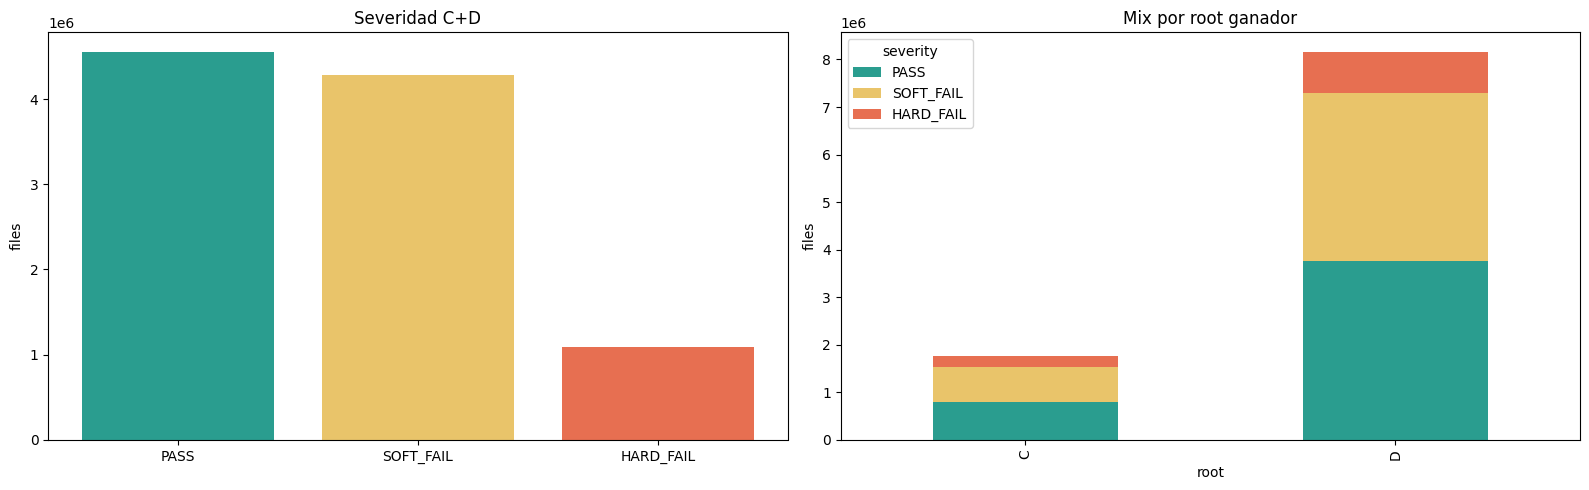

In [2]:
SCRIPT_10 = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\quotes\v1\cell_code\10_cd_run_snapshot.py")
mod10 = runpy.run_path(str(SCRIPT_10))

snapshot_payload_cd = mod00["build_snapshot_artifacts_cached"](quotes_handle_cd)
snapshot_cd = snapshot_payload_cd["snapshot"]
sev_counts_cd = snapshot_payload_cd["severity_counts"]
root_mix_cd = snapshot_payload_cd["root_mix"]

rows_snapshot_cd = None
rows_severity_cd = None
rows_root_mix_cd = None

show_table_cd(snapshot_cd, "snapshot_cd", rows=rows_snapshot_cd, transpose=True)
show_table_cd(sev_counts_cd, "sev_counts_cd", rows=rows_severity_cd)
show_table_cd(root_mix_cd, "root_mix_cd", rows=rows_root_mix_cd)
mod10["plot_snapshot_cd"](sev_counts_cd, root_mix_cd)


### 3. Raiz de los `HARD_FAIL` y de los warnings

Aqui interesa comprobar si el merge final esta dominado por una sola familia de fallo o por varias. En `quotes` la expectativa es ver peso fuerte de `crossed_ratio_*` y de `timestamp_out_of_partition_day`.

,issue,files,pct
0,crossed_ratio_gt_threshold,1090279,75.392303
1,crossed_ratio_gt_hard_cap,348895,24.125932
2,ask_integer_with_crossed_anomaly,6967,0.481765


,warn,files,pct
0,crossed_rows_present_but_under_threshold,3927750,84.089826
1,timestamp_out_of_partition_day,743148,15.910174


,issue,root,files
0,crossed_ratio_gt_threshold,D,866665
1,crossed_ratio_gt_hard_cap,D,275592
2,crossed_ratio_gt_threshold,C,223614
3,crossed_ratio_gt_hard_cap,C,73303
4,ask_integer_with_crossed_anomaly,D,5314
5,ask_integer_with_crossed_anomaly,C,1653


,warn,severity,files
0,crossed_rows_present_but_under_threshold,SOFT_FAIL,3927750
1,timestamp_out_of_partition_day,SOFT_FAIL,706582
2,timestamp_out_of_partition_day,HARD_FAIL,36566


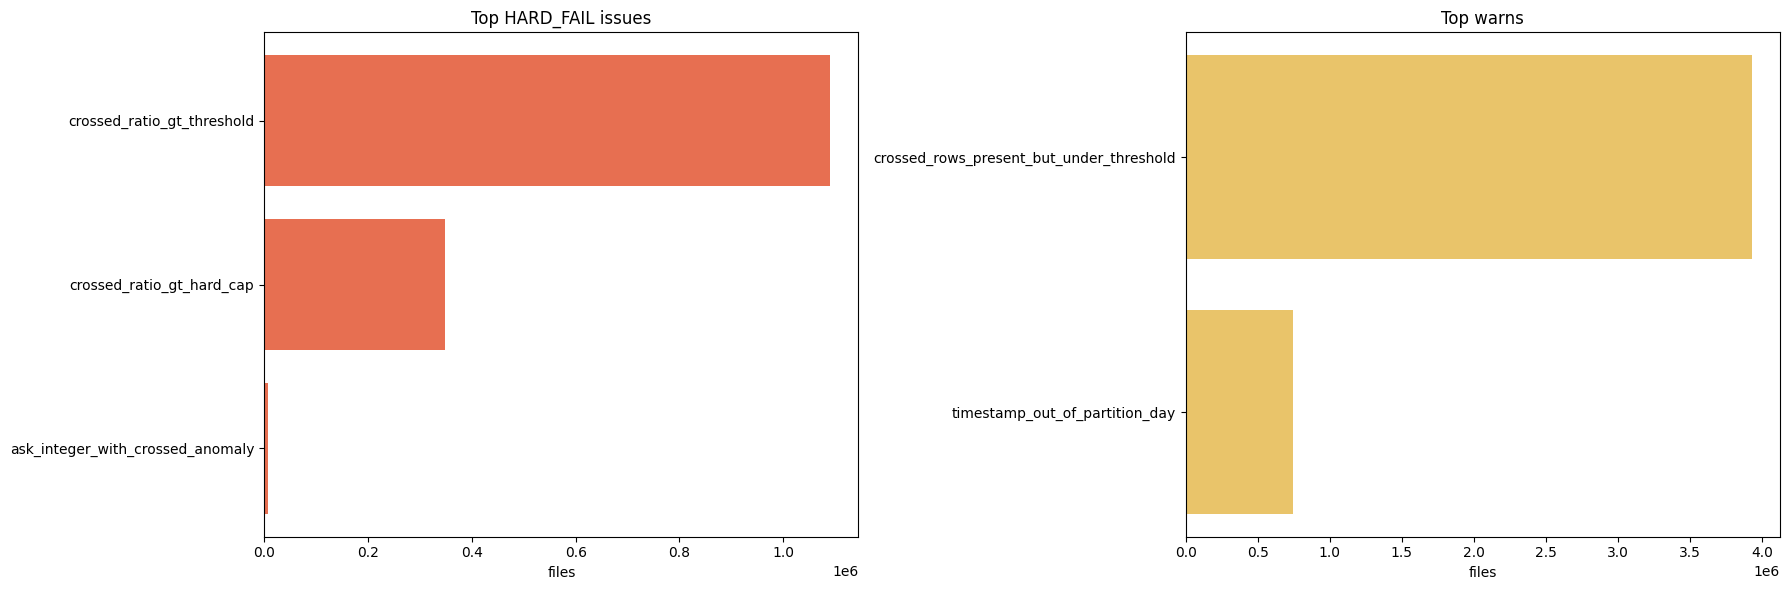

In [3]:
SCRIPT_11 = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\quotes\v1\cell_code\11_cd_root_cause_overview.py")
mod11 = runpy.run_path(str(SCRIPT_11))

root_payload_cd = mod00["build_root_cause_outputs_cached"](quotes_handle_cd)
hard_issue_counts_cd = root_payload_cd["hard_issue_counts"]
warn_counts_cd = root_payload_cd["warn_counts"]
issue_root_view_cd = root_payload_cd["issue_root_view"]
warn_severity_view_cd = root_payload_cd["warn_severity_view"]

rows_hard_issue_counts_cd = None
rows_warn_counts_cd = None
rows_issue_root_view_cd = None
rows_warn_severity_view_cd = None

show_table_cd(hard_issue_counts_cd, "hard_issue_counts_cd", rows=rows_hard_issue_counts_cd)
show_table_cd(warn_counts_cd, "warn_counts_cd", rows=rows_warn_counts_cd)
show_table_cd(issue_root_view_cd, "issue_root_view_cd", rows=rows_issue_root_view_cd)
show_table_cd(warn_severity_view_cd, "warn_severity_view_cd", rows=rows_warn_severity_view_cd)
mod11["plot_root_cause_overview_cd"](hard_issue_counts_cd, warn_counts_cd)


### 4. Donde se concentran los problemas

Se mide concentracion temporal y por ticker. En full importa ver si el residuo se reparte homogeneamente o si hay anos, meses o nombres donde la degradacion se dispara.

,month,PASS,SOFT_FAIL,HARD_FAIL,total,hard_fail_rate_pct,soft_fail_rate_pct
250,2025-11,12832,38173,3801,54806,6.935372,69.651133
251,2025-12,14972,43381,4585,62938,7.284947,68.926563
252,2026-01,8515,44009,4115,56639,7.265312,77.700877
253,2026-02,6241,44964,2358,53563,4.402293,83.946008
254,2026-03,5334,14639,740,20713,3.572636,70.675421


,year,PASS,SOFT_FAIL,HARD_FAIL,total,hard_fail_rate_pct,soft_fail_rate_pct
0,2005,95469,96454,64016,255939,25.012210,37.686324
1,2006,115918,118718,32615,267251,12.203883,44.421910
2,2007,75773,179889,26247,281909,9.310451,63.811017
3,2008,89835,178135,31018,298988,10.374329,59.579314
4,2009,98710,162666,39261,300637,13.059271,54.107113


,ticker,PASS,SOFT_FAIL,HARD_FAIL,total,hard_fail_rate_pct,soft_fail_rate_pct
0,MAYS,1331.0,286.0,3709.0,5326.0,69.639504,5.369884
1,GLBZ,1126.0,468.0,3683.0,5277.0,69.793443,8.868675
2,VBFC,1190.0,371.0,3411.0,4972.0,68.604183,7.461786
3,PBHC,1416.0,515.0,3388.0,5319.0,63.696183,9.682271
4,LARK,1140.0,814.0,3373.0,5327.0,63.318941,15.280646
5,INTG,1170.0,796.0,3361.0,5327.0,63.093674,14.942745
6,WVFC,771.0,313.0,3307.0,4391.0,75.313141,7.128217
7,HFBL,330.0,273.0,3199.0,3802.0,84.139926,7.180431
8,KFFB,1315.0,776.0,3194.0,5285.0,60.435194,14.683065
9,PLBC,1008.0,1086.0,3139.0,5233.0,59.984712,20.752914


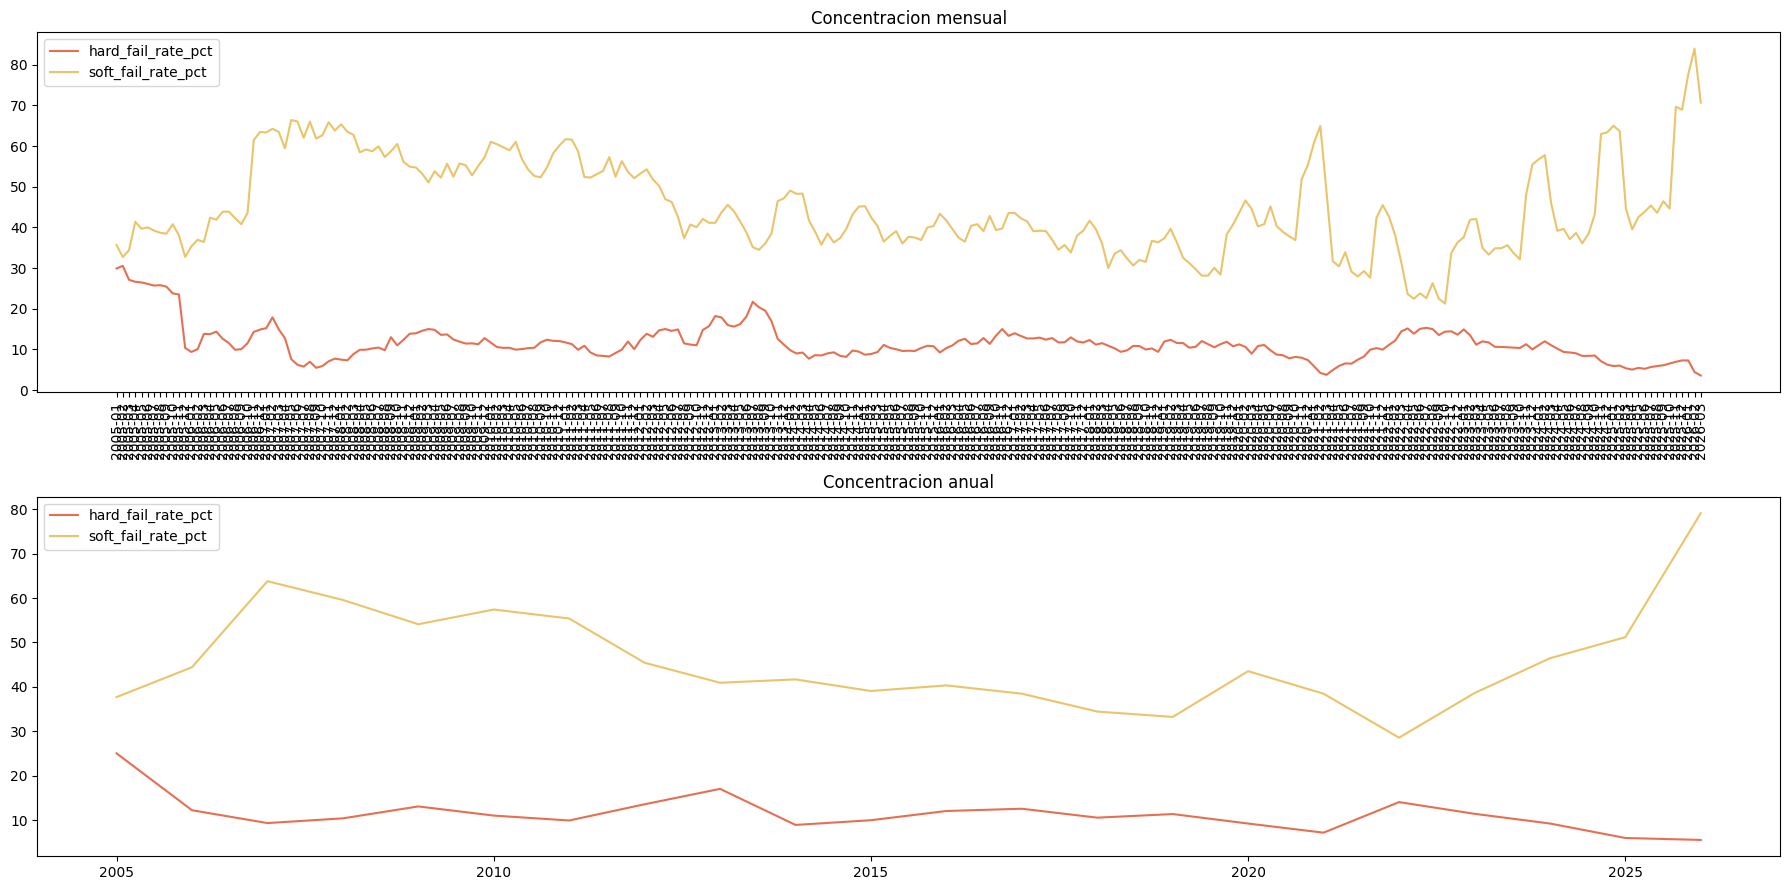

In [4]:
SCRIPT_12 = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\quotes\v1\cell_code\12_cd_problem_concentration.py")
mod12 = runpy.run_path(str(SCRIPT_12))

conc_payload_cd = mod00["build_concentration_artifacts_cached"](quotes_handle_cd, top_n=30)
month_rate_cd = conc_payload_cd["month_rate"]
year_rate_cd = conc_payload_cd["year_rate"]
ticker_concentration_cd = conc_payload_cd["ticker_focus"]

rows_month_rate_cd = 5
rows_year_rate_cd = 5
rows_ticker_concentration_cd = 10

show_table_cd(month_rate_cd, "month_rate_cd", rows=rows_month_rate_cd, tail=True)
show_table_cd(year_rate_cd, "year_rate_cd", rows=rows_year_rate_cd)
show_table_cd(ticker_concentration_cd, "ticker_concentration_cd", rows=rows_ticker_concentration_cd)
mod12["plot_time_concentration_cd"](month_rate_cd, year_rate_cd)


### 5. Diagnostico microestructural

Aqui se baja de la severidad agregada a las senales internas del validador: `crossed_ratio_pct`, `crossed_rows`, enterizacion de `ask`, redondeo de `ask` contra `bid` y drift de timestamps.

,ticker,date,root,severity,rows,m.crossed_ratio_pct,m.crossed_rows,m.ask_integer_pct,m.bid_integer_pct,m.ask_eq_round_bid_pct,issues_primary,warns_primary
0,ALR,2005-03-24,D,HARD_FAIL,1,100.0,1,100.0,0.0,100.0,ask_integer_with_crossed_anomaly,<NA>
1,BHAC,2015-03-19,D,HARD_FAIL,2,100.0,2,100.0,0.0,100.0,ask_integer_with_crossed_anomaly,<NA>
2,BHAC,2016-11-30,D,HARD_FAIL,14,100.0,14,100.0,0.0,100.0,ask_integer_with_crossed_anomaly,<NA>
3,BHAC,2018-02-07,D,HARD_FAIL,2,100.0,2,100.0,0.0,100.0,ask_integer_with_crossed_anomaly,<NA>
4,BHAC,2018-03-15,D,HARD_FAIL,2,100.0,2,100.0,0.0,100.0,ask_integer_with_crossed_anomaly,<NA>


,ticker,date,root,severity,rows,m.ts_min_utc,m.ts_max_utc,m.actual_timestamp_dates_utc,warns_primary
0,AMC,2021-01-27,D,SOFT_FAIL,2593648,2021-01-27T09:00:00.025557504+00:00,2021-01-28T00:59:59.989239552+00:00,"[""2021-01-27"", ""2021-01-28""]",crossed_rows_present_but_under_threshold
1,AMC,2021-02-01,D,SOFT_FAIL,2257580,2021-02-01T09:00:00.040036096+00:00,2021-02-02T00:59:59.313345792+00:00,"[""2021-02-01"", ""2021-02-02""]",crossed_rows_present_but_under_threshold
2,ACB,2020-11-06,D,SOFT_FAIL,2160920,2020-11-06T09:00:28.249172736+00:00,2020-11-07T00:59:48.514235136+00:00,"[""2020-11-06"", ""2020-11-07""]",crossed_rows_present_but_under_threshold
3,AMC,2021-02-25,D,SOFT_FAIL,1909456,2021-02-25T09:00:00.327383040+00:00,2021-02-26T00:59:59.841852416+00:00,"[""2021-02-25"", ""2021-02-26""]",crossed_rows_present_but_under_threshold
4,OCGN,2021-02-08,D,SOFT_FAIL,1900762,2021-02-08T09:00:00.022448959+00:00,2021-02-09T00:59:43.200210672+00:00,"[""2021-02-08"", ""2021-02-09""]",crossed_rows_present_but_under_threshold


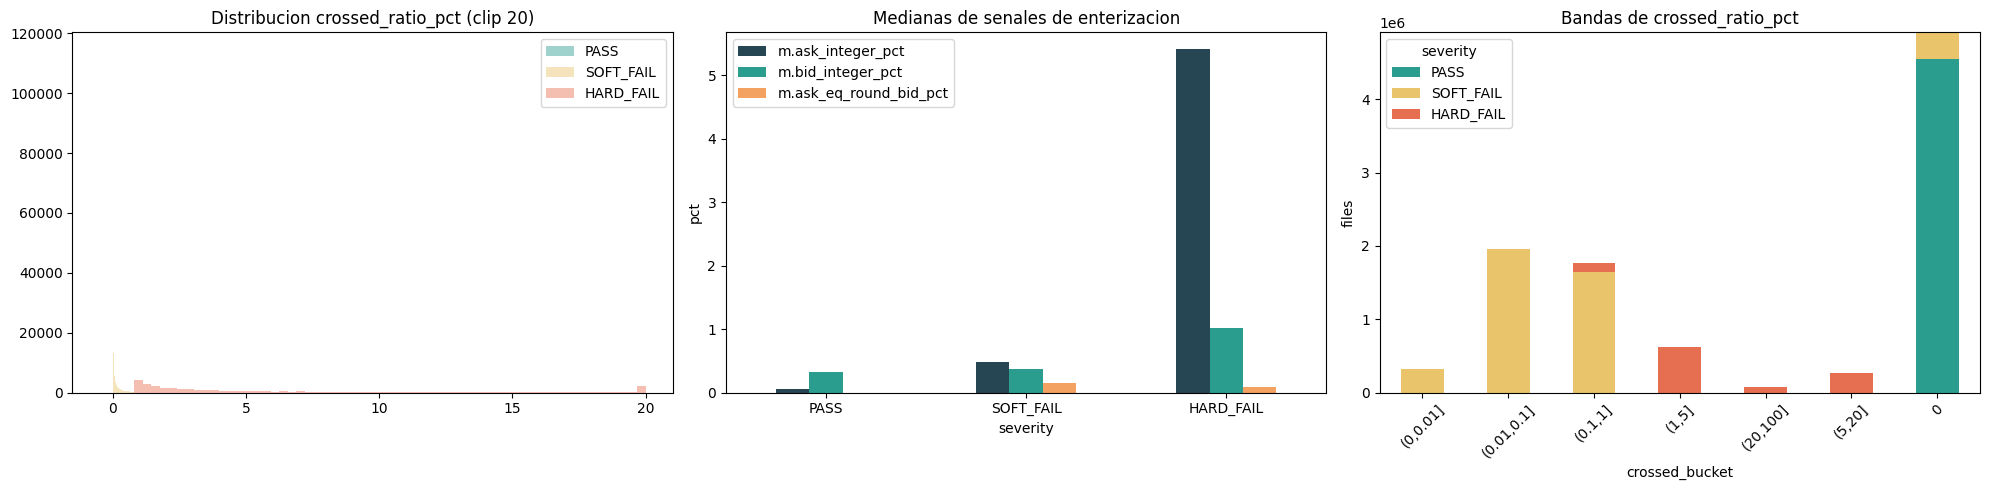

In [5]:
SCRIPT_13 = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\quotes\v1\cell_code\13_cd_microstructure_diagnostics.py")
mod13 = runpy.run_path(str(SCRIPT_13))

micro_payload_cd = mod00["build_microstructure_outputs_cached"](quotes_handle_cd, sample_max_n=250_000, top_n=25, random_state=7)
sample_cd = micro_payload_cd["sample_df"]
crossed_band_cd = micro_payload_cd["crossed_band"]
integer_anomaly_view_cd = micro_payload_cd["integer_anomaly_view"]
timestamp_view_cd = micro_payload_cd["timestamp_view"]

rows_integer_anomaly_view_cd = 5
rows_timestamp_view_cd = 5

show_table_cd(integer_anomaly_view_cd, "integer_anomaly_view_cd", rows=rows_integer_anomaly_view_cd)
show_table_cd(timestamp_view_cd, "timestamp_view_cd", rows=rows_timestamp_view_cd)
mod13["plot_microstructure_diagnostics_cd"](sample_cd, crossed_band_cd)

release_df("sample_cd")


### 6. Drill-down de ejemplos representativos

Se dejan ejemplos del issue duro dominante y del warning dominante para poder ir del agregado al caso concreto sin abrir manualmente todo el universo.

In [6]:
SCRIPT_14 = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\quotes\v1\cell_code\14_cd_drilldown_examples.py")
mod14 = runpy.run_path(str(SCRIPT_14))

FOCUS_ISSUE_CD, FOCUS_WARN_CD, issue_examples_cd, warn_examples_cd = mod00["build_focus_examples_cached"](quotes_handle_cd, hard_issue_counts_cd, warn_counts_cd, top_n=20)

rows_issue_examples_cd = 5
rows_warn_examples_cd = 5

display(Markdown(f"**FOCUS_ISSUE_CD:** `{FOCUS_ISSUE_CD}`"))
show_table_cd(issue_examples_cd, "issue_examples_cd", rows=rows_issue_examples_cd)
display(Markdown(f"**FOCUS_WARN_CD:** `{FOCUS_WARN_CD}`"))
show_table_cd(warn_examples_cd, "warn_examples_cd", rows=rows_warn_examples_cd)


**FOCUS_ISSUE_CD:** `crossed_ratio_gt_threshold`

,ticker,date,root,severity,rows,file,m.crossed_ratio_pct,m.crossed_rows,m.ask_integer_pct,m.ask_eq_round_bid_pct,m.timestamp_out_of_partition_day,issues_primary,warns_primary
0,DBVT,2014-12-29,D,HARD_FAIL,3160,D:\quotes\DBVT\year=2014\month=12\day=29\quote...,5.0,158,5.158228,0.094937,False,crossed_ratio_gt_threshold,<NA>
1,CSII,2012-12-18,D,HARD_FAIL,2000,D:\quotes\CSII\year=2012\month=12\day=18\quote...,5.0,100,5.400000,0.000000,False,crossed_ratio_gt_threshold,<NA>
2,RENT,2012-11-30,D,HARD_FAIL,1800,D:\quotes\RENT\year=2012\month=11\day=30\quote...,5.0,90,5.166667,0.000000,False,crossed_ratio_gt_threshold,<NA>
3,ATAI,2011-11-02,D,HARD_FAIL,1340,D:\quotes\ATAI\year=2011\month=11\day=02\quote...,5.0,67,10.522388,1.268657,False,crossed_ratio_gt_threshold,<NA>
4,LGP,2013-05-21,C,HARD_FAIL,1200,C:\TSIS_Data\data\quotes\LGP\year=2013\month=0...,5.0,60,7.000000,1.833333,False,crossed_ratio_gt_threshold,<NA>


**FOCUS_WARN_CD:** `crossed_rows_present_but_under_threshold`

,ticker,date,root,severity,rows,file,m.crossed_ratio_pct,m.crossed_rows,m.ask_integer_pct,m.ask_eq_round_bid_pct,m.timestamp_out_of_partition_day,issues_primary,warns_primary
0,PRGN,2009-09-21,D,SOFT_FAIL,14125,D:\quotes\PRGN\year=2009\month=09\day=21\quote...,0.8,113,0.000000,0.000000,False,<NA>,crossed_rows_present_but_under_threshold
1,NGVC,2013-10-15,D,SOFT_FAIL,9250,D:\quotes\NGVC\year=2013\month=10\day=15\quote...,0.8,74,1.243243,0.248649,False,<NA>,crossed_rows_present_but_under_threshold
2,STXS,2007-02-21,D,SOFT_FAIL,8750,D:\quotes\STXS\year=2007\month=02\day=21\quote...,0.8,70,1.074286,0.708571,False,<NA>,crossed_rows_present_but_under_threshold
3,HPP,2013-06-28,D,SOFT_FAIL,8625,D:\quotes\HPP\year=2013\month=06\day=28\quotes...,0.8,69,2.573913,1.866667,False,<NA>,crossed_rows_present_but_under_threshold
4,EMKR,2006-07-11,D,SOFT_FAIL,8000,D:\quotes\EMKR\year=2006\month=07\day=11\quote...,0.8,64,3.412500,3.387500,False,<NA>,crossed_rows_present_but_under_threshold


### 7. Forense file-level sobre `quotes.parquet`

Esta celda abre un caso real del merge final, carga el `quotes.parquet` original y dibuja `bid`, `ask`, `spread` y flag de mercado cruzado. Asi se puede comprobar si el problema es ruido marginal, deterioro persistente o patron de enterizacion.

,ticker,date,root,severity,rows,m.crossed_ratio_pct,m.crossed_rows,m.ask_integer_pct,m.ask_eq_round_bid_pct,file
0,CAK,2009-02-26,D,HARD_FAIL,45,100.0,45,100.0,0.000000,D:\quotes\CAK\year=2009\month=02\day=26\quotes...
1,WCFB,2016-12-29,D,HARD_FAIL,42,100.0,42,100.0,4.761905,D:\quotes\WCFB\year=2016\month=12\day=29\quote...
2,ICCC,2012-06-18,D,HARD_FAIL,31,100.0,31,100.0,0.000000,D:\quotes\ICCC\year=2012\month=06\day=18\quote...
3,AUBN,2017-07-12,D,HARD_FAIL,30,100.0,30,100.0,3.333333,D:\quotes\AUBN\year=2017\month=07\day=12\quote...
4,FSBC,2019-03-19,D,HARD_FAIL,29,100.0,29,100.0,6.896552,D:\quotes\FSBC\year=2019\month=03\day=19\quote...


**Caso inicial:** `CAK` `2009-02-26` root `D` severity `HARD_FAIL` crossed_ratio_pct `100.0000`

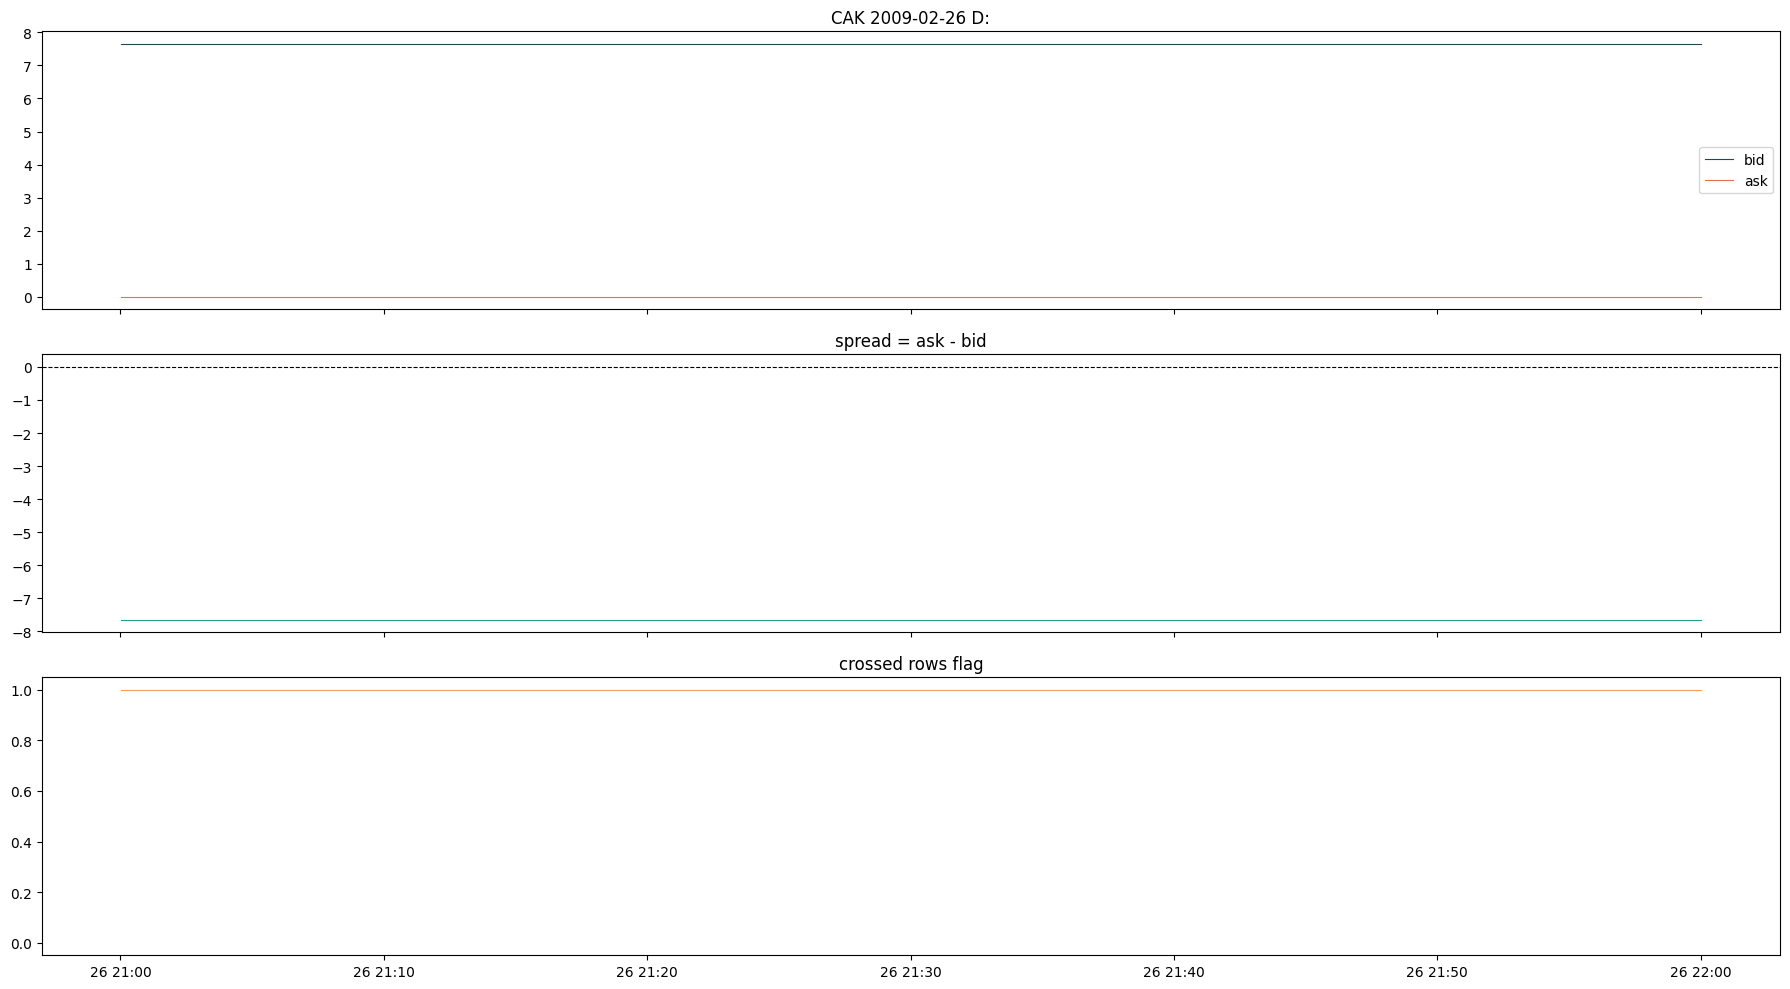

In [7]:
SCRIPT_15 = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\quotes\v1\cell_code\15_cd_forensic_widget.py")
mod15 = runpy.run_path(str(SCRIPT_15))
forensic_candidates_cd = mod00["build_forensic_candidates_cached"](quotes_handle_cd, initial_focus="HARD_FAIL", top_n=5)
forensic_ranked_cd = mod15["run_cd_forensic_widget"](forensic_candidates_cd, initial_focus="ALL", top_n=5)


### 8. Taxonomia operativa del residuo

El objetivo aqui ya no es contar issues sino agrupar el universo en familias operativas legibles: hard crossed market, soft crossed market persistente, timestamp shift, files pequenos con hard fail espurio y enterizacion anomala.

In [8]:
SCRIPT_16 = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\quotes\v1\cell_code\16_cd_taxonomy.py")
mod16 = runpy.run_path(str(SCRIPT_16))

quotes_taxonomy_summary_cd = mod00["build_taxonomy_summary_cached"](quotes_handle_cd)
rows_quotes_taxonomy_summary_cd = None
show_table_cd(quotes_taxonomy_summary_cd, "quotes_taxonomy_summary_cd", rows=rows_quotes_taxonomy_summary_cd)


,taxonomy,files,tickers,dates,hard_fail_files,soft_fail_files,crossed_ratio_median_pct,crossed_ratio_p90_pct,pct
0,clean_pass_or_other,4550938,5192,5337,0,0,0.000000,0.000000,45.828650
1,mild_crossed_micro_noise,2053010,4979,5336,0,2053010,0.031711,0.080032,20.674128
2,persistent_soft_crossed_market,1525894,5191,5336,0,1525894,0.246914,0.604098,15.365989
3,moderate_crossed_market,410231,4918,5335,410231,0,1.365188,3.208556,4.131090
4,timestamp_partition_shift,357736,4983,1721,0,357736,0.000000,0.000000,3.602457
5,soft_crossed_plus_timestamp_shift,348846,4909,1757,0,348846,0.055274,0.338983,3.512933
6,hard_crossed_market,341849,3472,5331,341849,0,10.000000,33.333333,3.442472
7,small_file_hard_crossed,331153,3328,5332,331153,0,2.380952,4.347826,3.334762
8,integerized_crossed_anomaly,7046,535,2463,7046,0,100.000000,100.000000,0.070954
9,rounded_ask_pattern_without_cross_hard,3631,1246,2472,0,0,0.000000,0.000000,0.036565


### 9. Lectura ejecutiva final

Ultima capa: condensar la lectura del full `C+D` en una tabla ejecutiva y en unas conclusiones que se puedan reutilizar en la auditoria general.

In [9]:
SCRIPT_17 = Path(r"C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\quotes\v1\cell_code\17_cd_exec_summary.py")
mod17 = runpy.run_path(str(SCRIPT_17))

sev_map_cd = sev_counts_cd.set_index("severity")["files"].to_dict()
exec_input_cd = snapshot_cd.copy()
rows_total_cd = float(exec_input_cd.iloc[0]["rows_total"])
exec_input_cd.loc[:, "hard_fail_files"] = int(sev_map_cd.get("HARD_FAIL", 0))
exec_input_cd.loc[:, "soft_fail_files"] = int(sev_map_cd.get("SOFT_FAIL", 0))
exec_input_cd.loc[:, "pass_files"] = int(sev_map_cd.get("PASS", 0))
exec_input_cd.loc[:, "hard_fail_rate_pct"] = float(exec_input_cd.iloc[0]["hard_fail_files"]) / rows_total_cd * 100.0
exec_input_cd.loc[:, "soft_fail_rate_pct"] = float(exec_input_cd.iloc[0]["soft_fail_files"]) / rows_total_cd * 100.0
exec_input_cd.loc[:, "timestamp_shift_rate_pct"] = float(exec_input_cd.iloc[0]["timestamp_out_of_partition_rows"]) / rows_total_cd * 100.0
exec_input_cd.loc[:, "crossed_ratio_p99_pct"] = float(exec_input_cd.iloc[0]["crossed_ratio_p99_pct"])

exec_summary_cd, exec_summary_md_cd = mod17["build_exec_summary_cd"](exec_input_cd, hard_issue_counts_cd, warn_counts_cd, quotes_taxonomy_summary_cd)
rows_exec_summary_cd = None
show_table_cd(exec_summary_cd, "exec_summary_cd", rows=rows_exec_summary_cd, transpose=True)
display(Markdown(exec_summary_md_cd))

release_df("forensic_candidates_cd", "exec_input_cd")


,0
rows_total,9930334
hard_fail_files,1090279
soft_fail_files,4285486
pass_files,4554569
top_hard_issue,crossed_ratio_gt_threshold
top_warn,crossed_rows_present_but_under_threshold
top_taxonomy,clean_pass_or_other
hard_fail_rate_pct,10.979278
soft_fail_rate_pct,43.155507
timestamp_shift_rate_pct,7.483615



### Lectura ejecutiva

- El `current` final `quotes C + D` contiene `9,930,334` files con `HARD_FAIL` `10.98%` y `SOFT_FAIL` `43.16%`.
- El issue duro dominante es `crossed_ratio_gt_threshold` y el warning dominante es `crossed_rows_present_but_under_threshold`.
- La taxonomía principal queda en `clean_pass_or_other`, lo que indica que el residuo no está repartido al azar sino concentrado en familias operativas repetibles.
- `timestamp_out_of_partition_day` aparece en `7.48%` del universo y pesa mucho más en `SOFT_FAIL` que en `HARD_FAIL`.
- El `p99` de `crossed_ratio_pct` está en `16.67%`, así que además del ruido micro hay una cola dura de files claramente deteriorados.
